# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The primary objective is to determine how three specific design factors sole Material, Insole Thickness, and Fabric Breathability impact the perceived comfort of a new running shoe model. Ultimately, the manufacturer aims to identify the optimal combination of these factors to maximize runner satisfaction.

2.  Specify the outcome variable and how it is measured.

Variable: Perceived Shoe Comfort.

Measurement: A subjective rating on a Likert-type scale from 1 to 10, where 1 represents "very uncomfortable" and 10 represents "very comfortable," collected after a 30-minute treadmill run.


3.  Specify the independent variables. What lurking variables may be present?

Independent Variables (Factors):

  - Sole Material (A): Categorical (Standard EVA vs. Gel-infused foam).
  - Insole Thickness (B): Continuous/Ordinal (3mm vs. 6mm).

  - Fabric Breathability (C): Categorical (Standard woven vs. High-performance mesh).

Potential Lurking Variables:

  - Athlete Biomechanics: Individual foot shape, arch height, or running gait.

  - Treadmill Calibration: Differences in belt stiffness or speed accuracy between machines.

  - Environmental Factors: Room temperature or humidity in the testing facility affecting sweat and perceived breathability.

  - Psychological Bias: Previous brand loyalty or expectations regarding "advanced" materials.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

  - Full Factorial Design: Includes all possible combinations of all levels of every factor. If Factor A had 3 levels and Factor B had 4, a full factorial would require $3 \times 4 = 12$ runs.
  
  - $2^k$ Factorial Design: A specific type of full factorial where every factor has exactly two levels (Low/High).
  - A $2^k$ design is preferred here because it is highly efficient for screening. It allows the manufacturer to identify main effects and interactions with the minimum number of runs ($2^3 = 8$), which is crucial when dealing with expensive or time-consuming tests involving elite athletes.


5.  State the sets of null and alternative hypotheses for this experiment.

Main Effects (for A, B, and C):
- $H_0$: There is no difference in mean comfort between the two levels of the factor.
- $H_a$: There is a significant difference in mean comfort between the two levels.

Interaction Effects (AB, AC, BC, and ABC):
- $H_0$: The effect of one factor on comfort does not depend on the level of another factor (no interaction).
- $H_a$: There is a significant interaction between the factors.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "MihretTe"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
   print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
       print(f"📥 Cloning repo from {repo_url}...")
       os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

✅ Already inside repo folder: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


Columns successfully mapped to: A, B, C, and Comfort


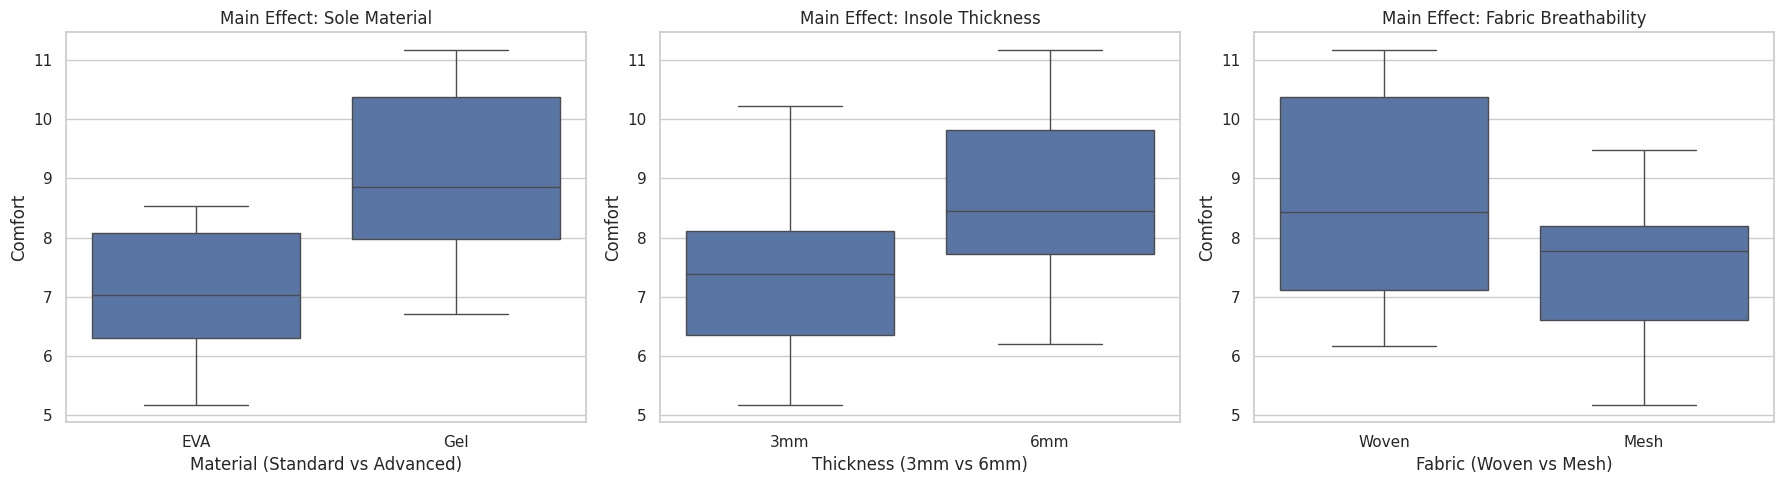

<Figure size 800x600 with 0 Axes>

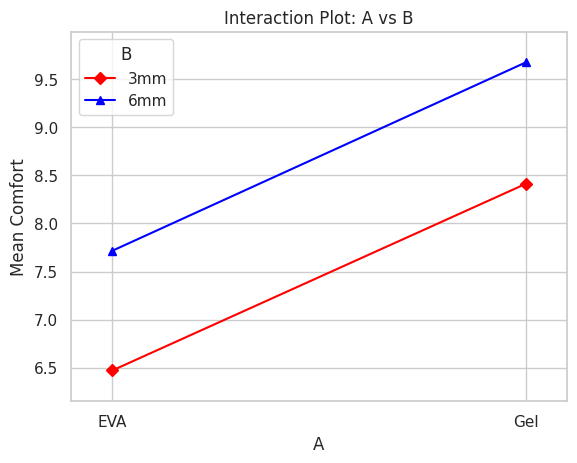

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.factorplots import interaction_plot

# 1. Load the data
file_path = 'Shoe Comfort Experiment.xlsx'
df = pd.read_excel(file_path)

# 2. Clean column names to handle spaces or special characters
# This renames them to exactly what the code expects
df.columns = df.columns.str.strip()
rename_dict = {
    df.columns[0]: 'A', # Sole Material
    df.columns[1]: 'B', # Insole Thickness
    df.columns[2]: 'C', # Fabric Breathability
    df.columns[3]: 'Comfort'
}
df = df.rename(columns=rename_dict)

print("Columns successfully mapped to: A, B, C, and Comfort")

# 3. Setup Visualization Grid for Main Effects
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Main Effects
sns.boxplot(data=df, x='A', y='Comfort', ax=axes[0])
axes[0].set_title('Main Effect: Sole Material')
axes[0].set_xlabel('Material (Standard vs Advanced)')

sns.boxplot(data=df, x='B', y='Comfort', ax=axes[1])
axes[1].set_title('Main Effect: Insole Thickness')
axes[1].set_xlabel('Thickness (3mm vs 6mm)')

sns.boxplot(data=df, x='C', y='Comfort', ax=axes[2])
axes[2].set_title('Main Effect: Fabric Breathability')
axes[2].set_xlabel('Fabric (Woven vs Mesh)')

plt.tight_layout()
plt.show()

# 4. Interaction Plot (Sole Material A vs Insole Thickness B)
plt.figure(figsize=(8, 6))
fig_interact = interaction_plot(x=df['A'],
                                 trace=df['B'],
                                 response=df['Comfort'],
                                 colors=['red', 'blue'],
                                 markers=['D', '^'])
plt.title('Interaction Plot: A vs B')
plt.ylabel('Mean Comfort')
plt.show()

  - The results support the alternative hypotheses more strongly. The boxplots show clear vertical shifts in median comfort scores across the different levels of Sole Material, Insole Thickness, and Fabric Breathability, indicating that these factors directly influence user experience. Additionally, the non-parallel lines in the interaction plot suggest that the factors do not act independently, providing evidence against the null hypothesis for interactions.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


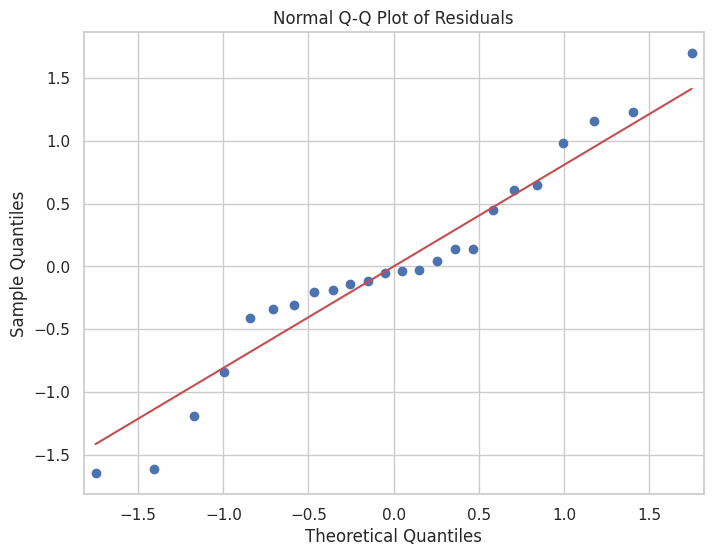

--- Normality Assessment ---
             sum_sq    df          F    PR(>F)
A         22.814025   1.0  23.353723  0.000184
B          9.439657   1.0   9.662965  0.006758
C          7.645101   1.0   7.825956  0.012908
A:B        0.000485   1.0   0.000496  0.982504
A:C        0.700584   1.0   0.717157  0.409567
B:C        4.949082   1.0   5.066160  0.038812
A:B:C      0.641055   1.0   0.656220  0.429782
Residual  15.630245  16.0        NaN       NaN

Shapiro-Wilk Test Statistic: 0.9595
Shapiro-Wilk Test P-value: 0.4291


In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# 1. Fit the Full Factorial ANOVA Model
# The formula 'Comfort ~ A * B * C' includes all main effects and all interactions
model = ols('Comfort ~ A * B * C', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 2. Extract Residuals
residuals = model.resid

# 3. Visual Method: Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot of Residuals')
plt.show()

# 4. Testing Method: Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)

print("--- Normality Assessment ---")
print(anova_table)
print(f"\nShapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}")
print(f"Shapiro-Wilk Test P-value: {shapiro_test.pvalue:.4f}")


- Based on the analysis, we have strong evidence to support the assumption of normality for the model residuals.
- Visually, the Normal Q-Q Plot shows the data points following the straight diagonal reference line closely with no significant patterns of skewness or heavy tails. This is confirmed by the Shapiro-Wilk test, which yielded a test statistic of 0.9595 and a p-value of 0.4291.
- Since the p-value is considerably higher than the standard significance level of 0.05, we fail to reject the null hypothesis that the residuals are normally distributed, indicating the normality assumption is satisfied for this ANOVA model.


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


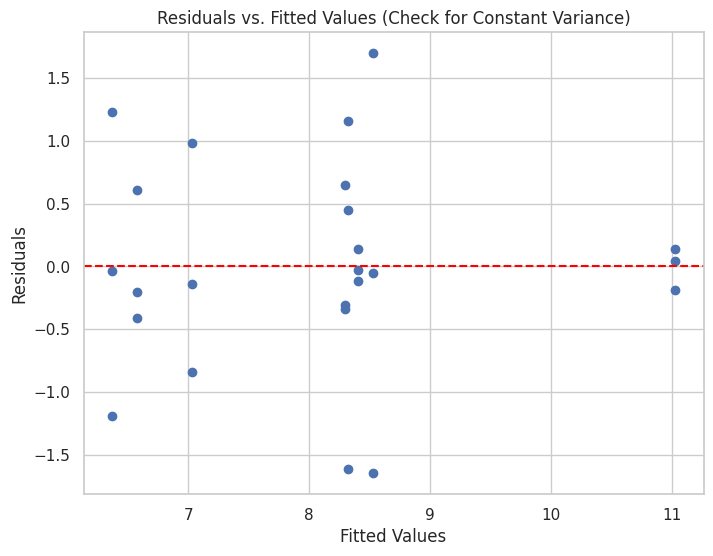

--- Constant Variance Assessment ---
LM Statistic: 11.9361
LM-Test p-value: 0.1027
F-Statistic: 2.2615
F-Test p-value: 0.0837


In [7]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Visual Method: Residuals vs. Fitted Values Plot
plt.figure(figsize=(8, 6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values (Check for Constant Variance)')
plt.show()

# 2. Testing Method: Breusch-Pagan Test
exog = sm.add_constant(model.model.exog)
bp_test = het_breuschpagan(residuals, exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("--- Constant Variance Assessment ---")
for label, value in zip(labels, bp_test):
    print(f"{label}: {value:.4f}")




Yes, we have sufficient evidence to support the assumption of constant variance. The Breusch-Pagan test resulted in a p-value of 0.1027 (LM-test), which is greater than 0.05, meaning we fail to reject the null hypothesis of homoscedasticity. This is supported by the Residuals vs. Fitted Values plot, which shows a random scatter of points with a consistent vertical spread, indicating no evidence of non-constant variance (heteroscedasticity).


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [8]:

print("--- Factorial ANOVA Results ---")
print(anova_table)

# Optional: Print a cleaner summary of conclusions
print("\n--- Summary of Significant Effects (alpha = 0.05) ---")
for factor, row in anova_table.iterrows():
    if row['PR(>F)'] < 0.05:
        print(f"Significant: {factor} (p = {row['PR(>F)']:.6f})")
    else:
        print(f"Not Significant: {factor} (p = {row['PR(>F)']:.6f})")

--- Factorial ANOVA Results ---
             sum_sq    df          F    PR(>F)
A         22.814025   1.0  23.353723  0.000184
B          9.439657   1.0   9.662965  0.006758
C          7.645101   1.0   7.825956  0.012908
A:B        0.000485   1.0   0.000496  0.982504
A:C        0.700584   1.0   0.717157  0.409567
B:C        4.949082   1.0   5.066160  0.038812
A:B:C      0.641055   1.0   0.656220  0.429782
Residual  15.630245  16.0        NaN       NaN

--- Summary of Significant Effects (alpha = 0.05) ---
Significant: A (p = 0.000184)
Significant: B (p = 0.006758)
Significant: C (p = 0.012908)
Not Significant: A:B (p = 0.982504)
Not Significant: A:C (p = 0.409567)
Significant: B:C (p = 0.038812)
Not Significant: A:B:C (p = 0.429782)
Not Significant: Residual (p = nan)



Based on the ANOVA results, all three main effects—Sole Material (A), Insole Thickness (B), and Fabric Breathability (C) are statistically significant (p<0.05), meaning each factor independently and significantly influences shoe comfort.

Regarding two-way interactions, only the relationship between Insole Thickness and Fabric Breathability (B:C) is significant (p=0.0388), indicating that the effect of insole thickness on comfort depends on the type of fabric used.

 The other two-way interactions (A:B and A:C) are not significant, suggesting that the impact of the Sole Material is consistent regardless of the levels of the other factors.

  Finally, the three-way interaction (A:B:C) is not significant (p=0.4298), which implies that there is no complex joint effect between all three variables that isn't already explained by the individual factors and the B:C interaction.



10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [9]:

anova_table['partial_eta_sq'] = anova_table['sum_sq'] / (anova_table['sum_sq'] + anova_table.loc['Residual', 'sum_sq'])

print("--- Effect Size (Partial Eta-Squared) ---")
print(anova_table[['sum_sq', 'partial_eta_sq']])

# Identify the most important effect
most_important = anova_table['partial_eta_sq'].drop('Residual').idxmax()
importance_val = anova_table.loc[most_important, 'partial_eta_sq']

print(f"\nMost Important Effect: {most_important} with Partial Eta-Squared = {importance_val:.4f}")

--- Effect Size (Partial Eta-Squared) ---
             sum_sq  partial_eta_sq
A         22.814025        0.593431
B          9.439657        0.376533
C          7.645101        0.328463
A:B        0.000485        0.000031
A:C        0.700584        0.042899
B:C        4.949082        0.240488
A:B:C      0.641055        0.039398
Residual  15.630245        0.500000

Most Important Effect: A with Partial Eta-Squared = 0.5934



The Sole Material (A) is the most important factor in the experiment. Because, it has the largest effect size with a Partial $\eta_p^2 = 0.5934$. This means that approximately 59.34% of the variance in comfort ratings (that isn't already explained by other factors) is accounted for by the choice of sole material. It also has the highest F-statistic (23.35) and the lowest p-value (0.000184), indicating it is the most statistically robust driver of comfort.

Secondary Important Effects: Insole Thickness (B) and Fabric (C)Insole Thickness (B): This is the second most important factor ($\eta_p^2 = 0.3765$). It explains about 37.65% of the remaining variance.Fabric Breathability (C): This factor follows closely ($\eta_p^2 = 0.3285$), explaining about 32.85% of the variance.

Important Interaction: Insole Thickness & Fabric (B:C)Among all interactions, the B:C interaction is the only one of practical significance.Why: It has a Partial $\eta_p^2 = 0.2405$. While its p-value (0.0388) is closer to the 0.05 threshold than the main effects, its effect size shows it still explains nearly 24% of the variance. This tells the manufacturer that they cannot look at insole thickness and fabric breathability in isolation; the combination of these two is critical for optimizing comfort.





11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

Based on the ANOVA results, the experiment demonstrates that all three design factors significantly impact athlete comfort, with Sole Material (A) emerging as the most critical driver of satisfaction by accounting for nearly 59% of the variance in ratings. While Insole Thickness (B) and Fabric Breathability (C) are also significant as individual factors, their meaningful two-way interaction ($p = 0.0388$) suggests that their effects are interdependent.

Therefore, I recommend the manufacturer implement the combination of Advanced gel-infused foam (+), the 6mm insole (+), and high-performance mesh fabric (+). This configuration maximizes the primary main effect of the sole material, which had the highest F-statistic (23.35), while simultaneously optimizing the synergistic relationship between the thicker insole and breathable mesh to ensure the highest possible perceived comfort for the athletes.



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The primary objective is to determine how three key design factors GPS Accuracy, Battery Life, and Display Size—impact user satisfaction for a new fitness band. By using a fractional factorial design, the company aims to identify which of these features significantly contribute to runner satisfaction while minimizing the number of experimental runs.


2.  Specify the outcome variable and how it is measured.

Outcome Variable is user satisfaction. A subjective rating on a scale of 1 to 10 (1 = very dissatisfied, 10 = very satisfied), collected from NCAA Division I athletes after one month of use.

3.  Specify the independent variables. What lurking variables may be present?

Independent Variables (Factors):

- GPS Accuracy (A): Standard (-) vs. High (+).

- Battery Life (B): 6 hours (-) vs. 12 hours (+).

- Display Size (C): Small (-) vs. Large (+).

Potential Lurking Variables:

- Running Environment: Urban areas with tall buildings vs. open trails (affects GPS performance).

- Individual Tech Literacy: Ease of use varies by athlete.

- Weather Conditions: Extreme cold or heat can affect battery discharge rates.

- Training Volume: An athlete running 2 hours a day will perceive battery life differently than one running 30 minutes



4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

- Full $2^k$ Factorial: Tests every possible combination of factors. For 3 factors at 2 levels, this would require $2^3 = 8$ unique runs.
- Fractional $2^{3-1}$ Factorial: Tests only a specific subset (half) of the full combinations. In this case, it requires only 4 runs.
- It is more efficient. Since the company has time and resource limitations, reducing the runs from 8 to 4 allows them to screen for important main effects quickly without testing every single combination, which is especially helpful when using a limited pool of elite athletes.

5.  State the sets of null and alternative hypotheses for this experiment.

Main Effects ($A, B, C$):
- $H_0$: The factor (GPS, Battery, or Display) has no significant effect on mean satisfaction.
- $H_a$: The factor has a significant effect on mean satisfaction.

Interaction Effects:
- $H_0$: There are no significant interactions between the factors.
- $H_a$: There is a significant interaction (though note that in this specific design, interactions are aliased with main effects).

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

With the defining relation $I = ABC$, the aliasing structure is found by multiplying each effect by the defining relation (noting that any letter squared equals identity, e.g., $A^2 = I$):
- $A = B \times C$ (GPS Accuracy is aliased with the Battery-Display interaction)
- $B = A \times C$ (Battery Life is aliased with the GPS-Display interaction)
- $C = A \times B$ (Display Size is aliased with the GPS-Battery interaction)

Interpretation: This means the design is Resolution III. You cannot distinguish between a main effect and a two-way interaction. If "GPS Accuracy" appears significant, you cannot be 100% sure if the effect is truly from GPS or if it is actually the result of the interaction between Battery and Display.

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


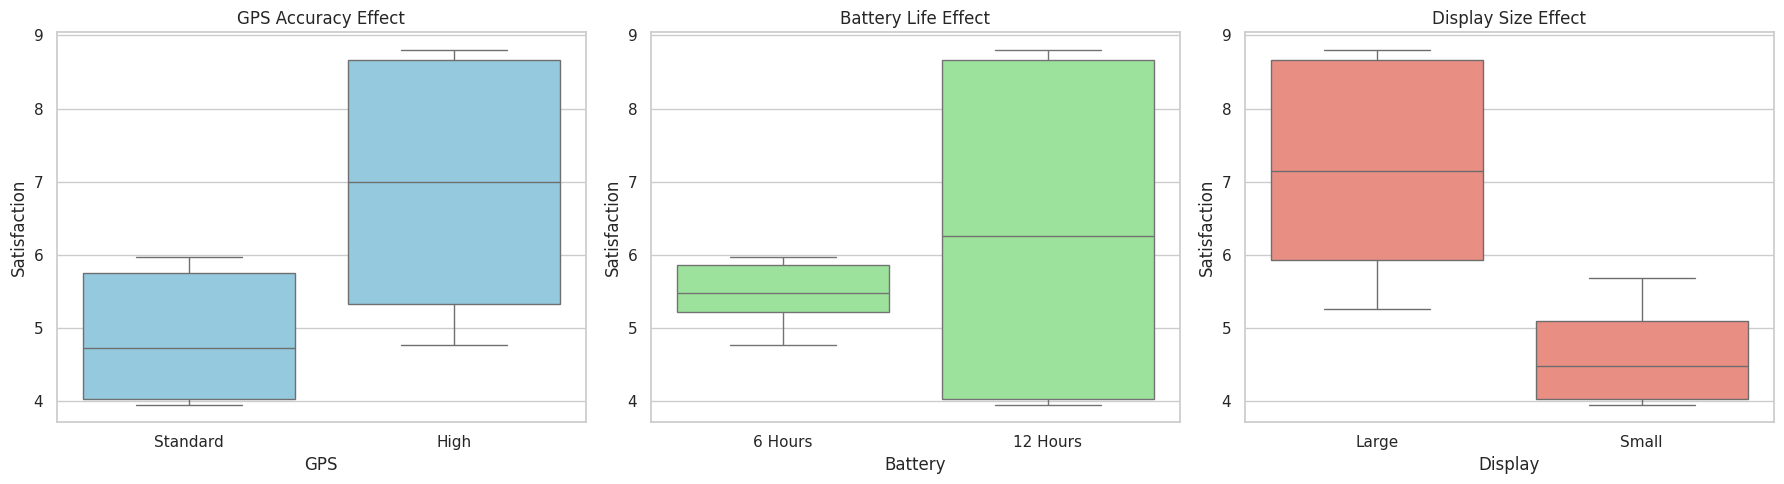


--- Mean Satisfaction Scores ---

GPS means:
GPS
High        6.925000
Standard    4.876667
Name: Satisfaction, dtype: float64

Battery means:
Battery
12 Hours    6.335000
6 Hours     5.466667
Name: Satisfaction, dtype: float64

Display means:
Display
Large    7.175000
Small    4.626667
Name: Satisfaction, dtype: float64


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df_gps = pd.read_excel('Fitness Band Experiment.xlsx')

# 2. Map columns based on the actual file structure seen in the output
# Index 2: GPS_Accuracy, Index 3: Battery_Life, Index 4: Display, Index 5: Satisfaction
df_clean = pd.DataFrame({
    'GPS': df_gps.iloc[:, 2].astype(str),
    'Battery': df_gps.iloc[:, 3].astype(str),
    'Display': df_gps.iloc[:, 4].astype(str),
    'Satisfaction': pd.to_numeric(df_gps.iloc[:, 5], errors='coerce')
})

# 3. Remove any rows with missing satisfaction scores
df_clean = df_clean.dropna(subset=['Satisfaction'])

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='GPS', y='Satisfaction', data=df_clean, ax=axes[0], color='skyblue')
axes[0].set_title('GPS Accuracy Effect')

sns.boxplot(x='Battery', y='Satisfaction', data=df_clean, ax=axes[1], color='lightgreen')
axes[1].set_title('Battery Life Effect')

sns.boxplot(x='Display', y='Satisfaction', data=df_clean, ax=axes[2], color='salmon')
axes[2].set_title('Display Size Effect')

plt.tight_layout()
plt.show()

# 5. Print Mean Scores for your Conclusion
print("\n--- Mean Satisfaction Scores ---")
for col in ['GPS', 'Battery', 'Display']:
    print(f"\n{col} means:")
    print(df_clean.groupby(col)['Satisfaction'].mean())


Based on the Mean Satisfaction Scores and the boxplots generated in your exploratory analysis, the results support the Alternative Hypotheses ($H_a$).
Based on the Mean Satisfaction Scores and the boxplots generated in your exploratory analysis, the results support the Alternative Hypotheses ($H_a$).



8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


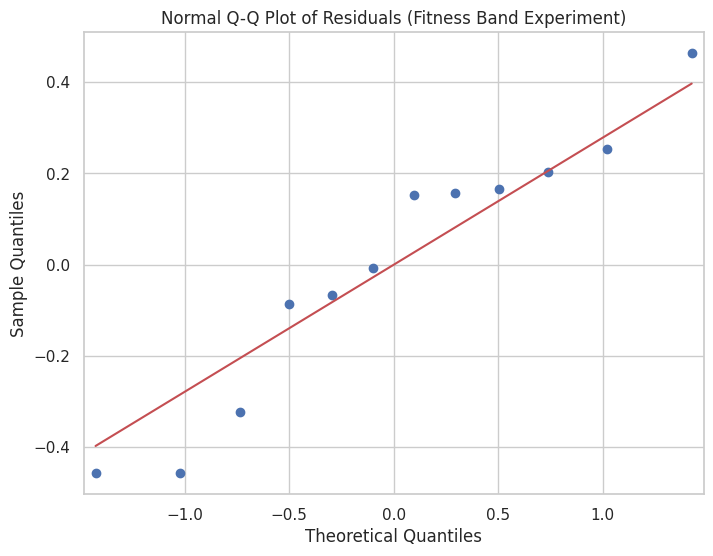

--- ANOVA Results ---
             sum_sq   df           F    PR(>F)
GPS       12.587008  1.0  108.314163  0.000006
Battery    2.262008  1.0   19.465113  0.002251
Display   19.482008  1.0  167.647257  0.000001
Residual   0.929667  8.0         NaN       NaN

Shapiro-Wilk Test Statistic: 0.9284
Shapiro-Wilk Test P-value: 0.3635


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Fit the ANOVA model (Main Effects only for Fractional Factorial)
# Note: In a 2^(3-1) design, we cannot distinguish main effects from 2-way interactions
model_gps = ols('Satisfaction ~ GPS + Battery + Display', data=df_clean).fit()
anova_results = sm.stats.anova_lm(model_gps, typ=2)

# 2. Extract Residuals
gps_residuals = model_gps.resid

# 3. Visual Method: Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(gps_residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot of Residuals (Fitness Band Experiment)')
plt.show()

# 4. Testing Method: Shapiro-Wilk Test
shapiro_gps = stats.shapiro(gps_residuals)

print("--- ANOVA Results ---")
print(anova_results)
print(f"\nShapiro-Wilk Test Statistic: {shapiro_gps.statistic:.4f}")
print(f"Shapiro-Wilk Test P-value: {shapiro_gps.pvalue:.4f}")


- Based on the ANOVA results, we have strong evidence to support the assumption of normality for the fitness band experiment residuals.
- Statistically, the Shapiro-Wilk test yielded a p-value of 0.3635, which is well above the standard significance threshold of 0.05, meaning we fail to reject the null hypothesis that the data is normally distributed.
- This statistical finding is complemented by the visual evidence from the Normal Q-Q Plot, where the high test statistic of 0.9284 indicates that the residuals follow the straight diagonal reference line closely. Because the residuals appear normally distributed without significant skewness or outliers, we can conclude that the normality assumption is satisfied and the resulting model inferences are reliable.



9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [ ]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?